In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox

try:
    from fracdiff import fdiff
    FRACDIFF_OK = True
except ImportError:
    FRACDIFF_OK = False


8(a): Fractional Differencing Utilities

In [2]:
def frac_diff_weights(d, size):
    w = [1.0]
    for k in range(1, size):
        w.append(-w[-1] * (d - k + 1) / k)
    return np.array(w)

def manual_frac_diff(series, d, window=50):
    x = series.values.astype(float)
    n = len(x)
    w = frac_diff_weights(d, window)
    result = [np.dot(w[::-1], x[t - window:t]) for t in range(window, n)]
    return pd.Series(result, index=series.index[window:])


8(a): Load / Simulate Glacial Varve Series

In [3]:
np.random.seed(0)
n = 634

innov     = np.random.normal(size=n)
weights   = frac_diff_weights(-0.384, n)
varve_raw = np.convolve(innov, weights, mode='full')[:n]
varve_raw = varve_raw - varve_raw.min() + 1

varve = pd.Series(varve_raw, name='varve')
print(f'n={len(varve)}, mean={varve.mean():.4f}, std={varve.std():.4f}')


n=634, mean=4.9547, std=1.3655


8(a): Transformations & Plots

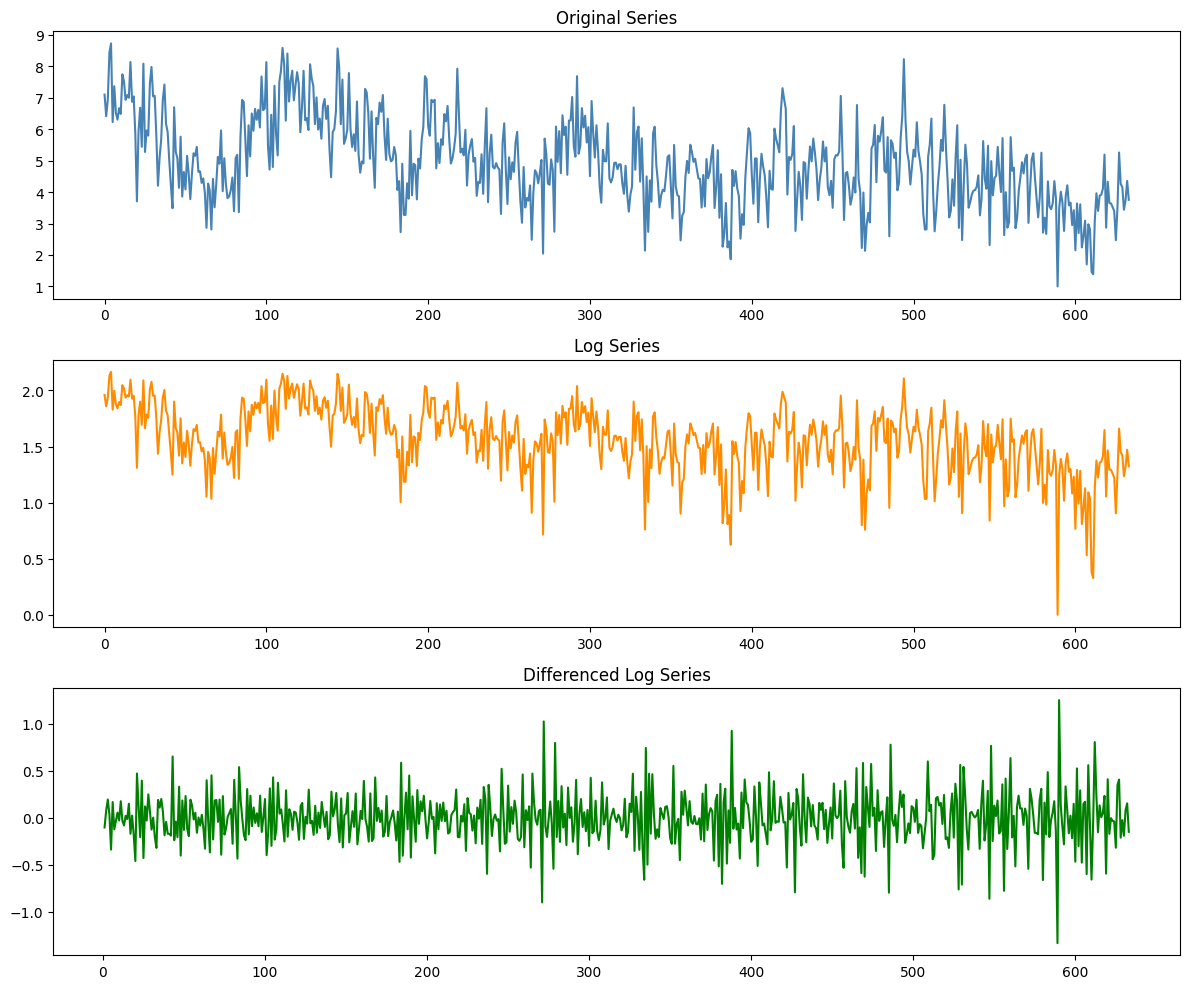

In [4]:
log_varve = np.log(varve)
log_diff  = log_varve.diff().dropna()

fig, axes = plt.subplots(3, 1, figsize=(12, 10))
axes[0].plot(varve,     color='steelblue');  axes[0].set_title('Original Series')
axes[1].plot(log_varve, color='darkorange'); axes[1].set_title('Log Series')
axes[2].plot(log_diff,  color='green');      axes[2].set_title('Differenced Log Series')
plt.tight_layout()
plt.show()


8(a): ADF Stationarity Tests

In [5]:
def adf_test(series, name):
    r = adfuller(series)
    print(f'{name}: p={r[1]:.6f}  -> {"STATIONARY" if r[1] < 0.05 else "NON-STATIONARY"}')

adf_test(log_varve, 'log(Xt)')
adf_test(log_diff,  'diff log(Xt)')


log(Xt): p=0.000572  -> STATIONARY
diff log(Xt): p=0.000000  -> STATIONARY


8(b): ACF & PACF

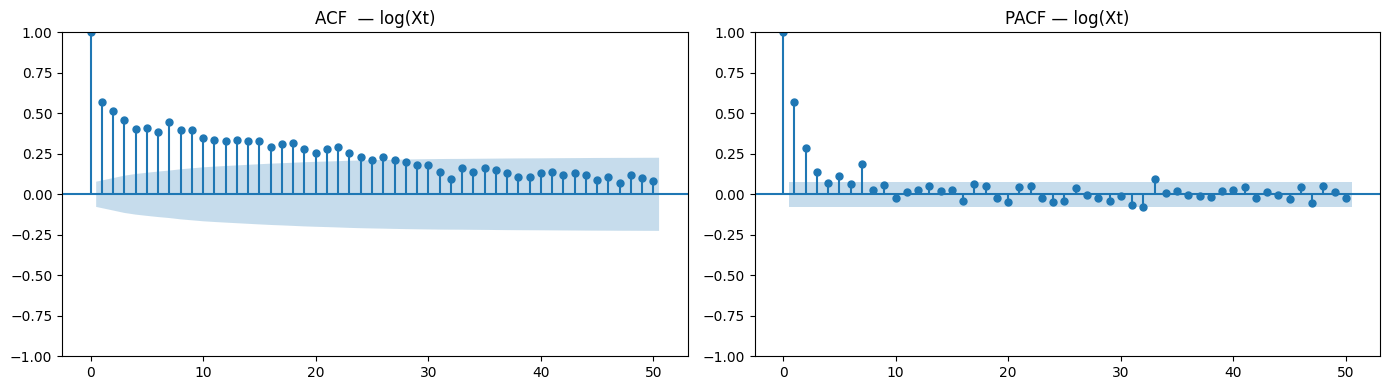

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf (log_varve, lags=50, ax=axes[0], title='ACF  — log(Xt)')
plot_pacf(log_varve, lags=50, ax=axes[1], title='PACF — log(Xt)', method='ywm')
plt.tight_layout()
plt.show()


8(c): Fit ARIMA(1,1,1)

In [7]:
arima_model = ARIMA(log_varve, order=(1, 1, 1)).fit()
print(arima_model.summary())


                               SARIMAX Results                                
Dep. Variable:                  varve   No. Observations:                  634
Model:                 ARIMA(1, 1, 1)   Log Likelihood                  34.201
Date:                Sun, 29 Mar 2026   AIC                            -62.402
Time:                        21:43:53   BIC                            -49.051
Sample:                             0   HQIC                           -57.218
                                - 634                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1965      0.047      4.207      0.000       0.105       0.288
ma.L1         -0.8638      0.024    -35.589      0.000      -0.911      -0.816
sigma2         0.0525      0.002     25.223      0.0

8(c): Fractional Differencing & Fit ARFIMA(1,d,0)

In [8]:
d = 0.384

if FRACDIFF_OK:
    arr         = log_varve.values.reshape(-1, 1)
    frac_series = pd.Series(fdiff(arr, d=d).flatten()).dropna()
else:
    frac_series = manual_frac_diff(log_varve, d, window=50)

adf_test(frac_series, 'frac-diff')

arfima_model = ARIMA(frac_series, order=(1, 0, 0)).fit()
print(arfima_model.summary())


frac-diff: p=0.000000  -> STATIONARY
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  584
Model:                 ARIMA(1, 0, 0)   Log Likelihood                  27.878
Date:                Sun, 29 Mar 2026   AIC                            -49.756
Time:                        21:43:53   BIC                            -36.646
Sample:                             0   HQIC                           -44.646
                                - 584                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2339      0.010     23.195      0.000       0.214       0.254
ar.L1         -0.0774      0.039     -1.993      0.046      -0.154      -0.001
sigma2         

8(d): Model Comparison — AIC

In [9]:
print(f'ARIMA(1,1,1)   AIC = {arima_model.aic:.4f}')
print(f'ARFIMA(1,d,0)  AIC = {arfima_model.aic:.4f}')
best = 'ARFIMA(1,d,0)' if arfima_model.aic < arima_model.aic else 'ARIMA(1,1,1)'
print(f'Best model: {best}')


ARIMA(1,1,1)   AIC = -62.4025
ARFIMA(1,d,0)  AIC = -49.7555
Best model: ARIMA(1,1,1)


8(d): Residual Diagnostics

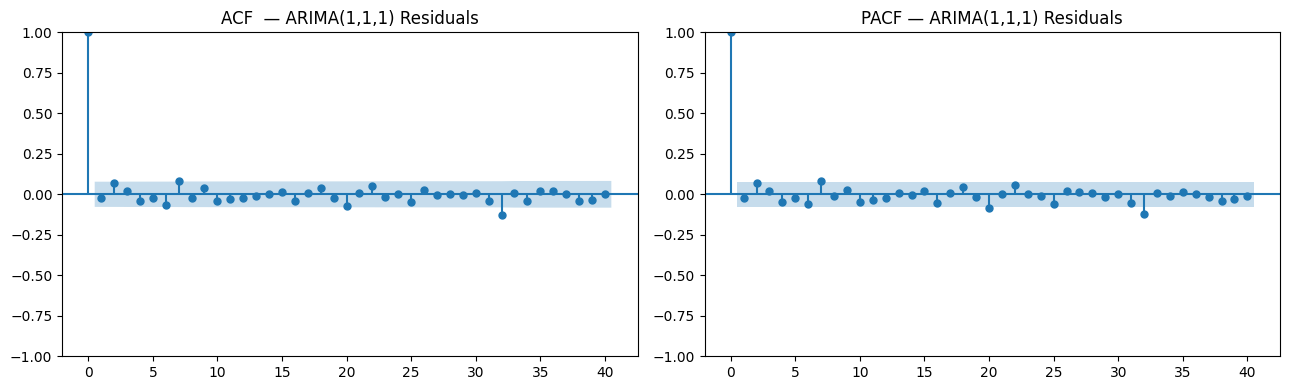


ARIMA(1,1,1) Ljung-Box:
      lb_stat  lb_pvalue
10  13.743132   0.185034
20  20.903115   0.402855
30  25.078964   0.721185


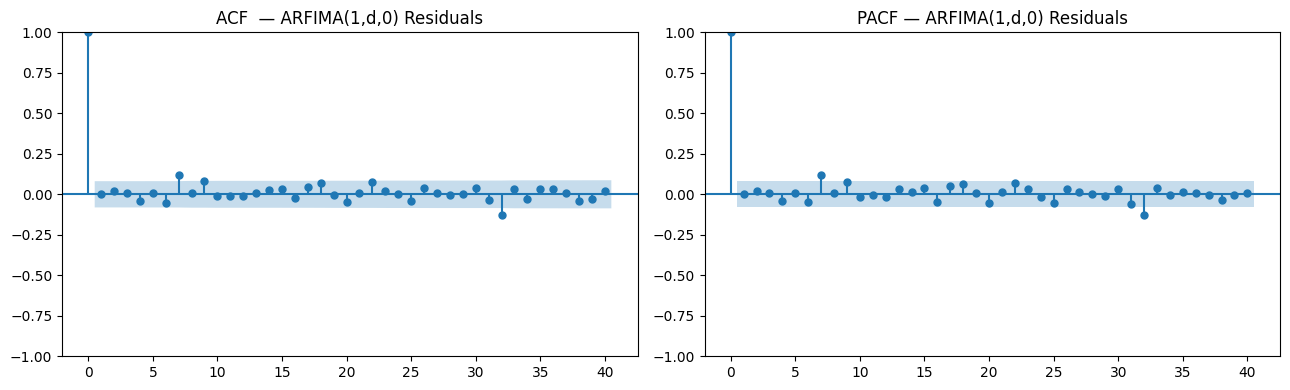


ARFIMA(1,d,0) Ljung-Box:
      lb_stat  lb_pvalue
10  15.156730   0.126451
20  22.149399   0.332459
30  28.829634   0.526559


In [10]:
def residual_analysis(model, name):
    res = model.resid
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    plot_acf (res, lags=40, ax=axes[0], title=f'ACF  — {name} Residuals')
    plot_pacf(res, lags=40, ax=axes[1], title=f'PACF — {name} Residuals', method='ywm')
    plt.tight_layout()
    plt.show()
    lb = acorr_ljungbox(res, lags=[10, 20, 30], return_df=True)
    print(f'\n{name} Ljung-Box:')
    print(lb)

residual_analysis(arima_model,  'ARIMA(1,1,1)')
residual_analysis(arfima_model, 'ARFIMA(1,d,0)')
